# **Разработка модели оценки стоимости футбольных трансферов**

In [ ]:
!pip install kagglehub -q

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [ ]:
import kagglehub
path = kagglehub.dataset_download("xfkzujqjvx97n/football-datasets")

def load_csv(file_path, description=""):
    full_path = os.path.join(path, file_path)
    df = pd.read_csv(full_path, low_memory=False)
    print(f"   {description:30}: {len(df):8,} строк, {len(df.columns):3d} колонок")
    return df

transfer_history = load_csv('transfer_history/transfer_history.csv', "История трансферов")
player_profiles = load_csv('player_profiles/player_profiles.csv', "Профили игроков")
market_values = load_csv('player_market_value/player_market_value.csv', "Рыночная стоимость")
player_performances = load_csv('player_performances/player_performances.csv', "Выступления игроков")
player_injuries = load_csv('player_injuries/player_injuries.csv', "Травмы игроков")
player_national = load_csv('player_national_performances/player_national_performances.csv', "Сборная")

Using Colab cache for faster access to the 'football-datasets' dataset.
   История трансферов            : 1,101,440 строк,  10 колонок
   Профили игроков               :   92,671 строк,  34 колонок
   Рыночная стоимость            :  901,429 строк,   3 колонок
   Выступления игроков           : 1,878,719 строк,  20 колонок
   Травмы игроков                :  143,195 строк,   7 колонок
   Сборная                       :   92,701 строк,   9 колонок


In [ ]:
def extract_season_year(season):
    if pd.isna(season):
        return None
    s = str(season).strip()
    if '/' in s:
        first = s.split('/')[0]
        if len(first) == 4:
            return int(first)
        elif len(first) == 2:
            return 2000 + int(first) if int(first) < 50 else 1900 + int(first)
    if s.isdigit() and len(s) == 4:
        return int(s)
    return None


def get_age_group(age):
    if pd.isna(age):
        return 'Unknown'
    if age < 20:
        return '<20'
    elif age < 24:
        return '20-24'
    elif age < 28:
        return '24-27'
    elif age < 31:
        return '27-30'
    elif age < 34:
        return '30-33'
    elif age < 37:
        return '33-37'
    else:
        return '37+'


def calculate_advanced_metrics(df_perf):
    df = df_perf.copy()
    if 'goals' in df.columns and 'assists' in df.columns and 'minutes_played' in df.columns:
        df['goals_assists_per_90'] = (df['goals'] + df['assists']) / (df['minutes_played'] / 90 + 1e-5)
        df['goals_assists_per_90'] = df['goals_assists_per_90'].replace([np.inf, -np.inf], 0).fillna(0)
    if 'penalty_goals' in df.columns and 'goals' in df.columns:
        df['non_penalty_goals'] = df['goals'] - df['penalty_goals'].fillna(0)
    if 'clean_sheets' in df.columns and 'goals_conceded' in df.columns:
        df['clean_sheet_ratio'] = df['clean_sheets'] / (df['goals_conceded'] + 1)
    return df

In [ ]:
df_transfers = transfer_history[transfer_history['transfer_fee'] > 0].copy() # Оставляем только платные трансферы

df_transfers['log_fee'] = np.log1p(df_transfers['transfer_fee']) # Логарифмическое преобразование целевой переменной

df_transfers['season_year'] = df_transfers['season_name'].apply(extract_season_year) # Извлечение года из сезона

df_transfers = df_transfers.dropna(subset=['transfer_date', 'player_id']) # Удаляем трансферы без даты или ID игрока

print(f"Платных трансферов: {len(df_transfers):,}")

Платных трансферов: 39,997


In [ ]:
# Преобразование дат
player_profiles['birth_date'] = pd.to_datetime(player_profiles['date_of_birth'], errors='coerce')
df_transfers['transfer_date'] = pd.to_datetime(df_transfers['transfer_date'], errors='coerce')

# Объединение с профилями игроков
df = df_transfers.merge(
    player_profiles[['player_id', 'birth_date', 'position', 'height', 'foot']],
    on='player_id',
    how='left'
)

# Расчет возраста в годах с точностью до дня
df['age'] = (df['transfer_date'] - df['birth_date']).dt.days / 365.25
df['age'] = df['age'].round(0)

# Заполнение пропусков возраста медианным значением
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)

# Генерация признаков для моделирования нелинейного влияния возраста
df['age_squared'] = df['age'] ** 2
df['age_group'] = df['age'].apply(get_age_group)

print(f"Возраст рассчитан, медиана: {age_median:.1f} лет")
print(f"Средний возраст: {df['age'].mean():.0f} лет")
print(f"Минимальный: {df['age'].min():.1f}, максимальный: {df['age'].max():.1f}")
print(f"Распределение по возрастным группам:")
print(df['age_group'].value_counts().to_string())

Возраст рассчитан, медиана: 24.0 лет
Средний возраст: 24 лет
Минимальный: 7.0, максимальный: 39.0
Распределение по возрастным группам:
age_group
24-27    17307
20-24    12298
27-30     4829
<20       3612
30-33     1633
33-37      293
37+         25


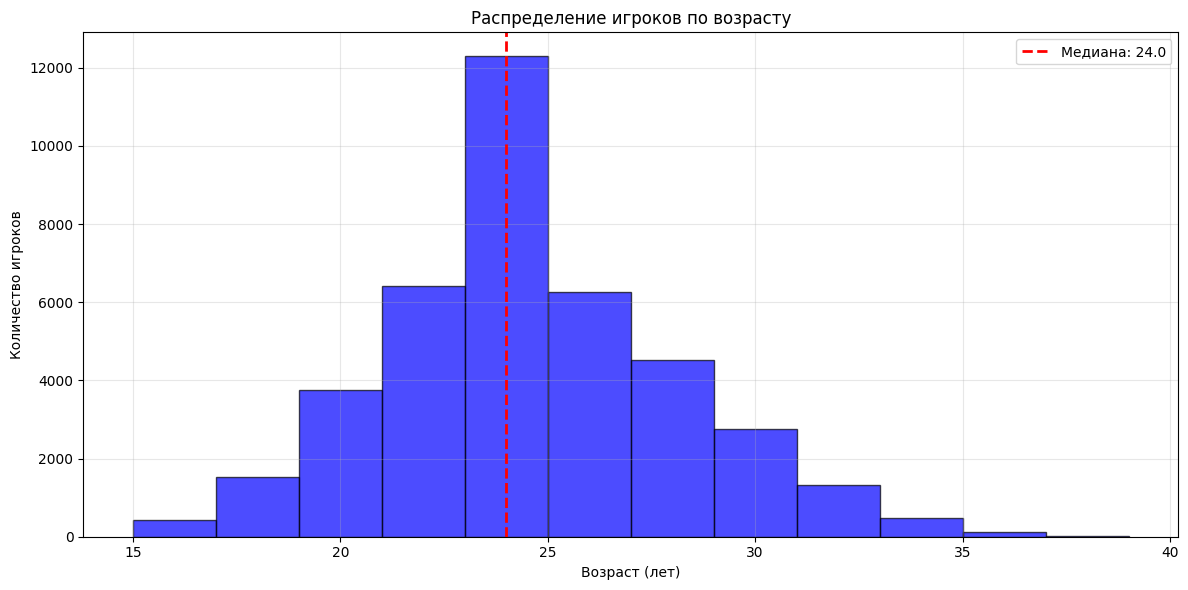

In [ ]:
# 5. Разведочный анализ данных (EDA)

fig, ax = plt.subplots(figsize=(12, 6))

# 5.1. Распределение по возрасту
age_bins = np.arange(15, 41, 2)
ax.hist(df['age'], bins=age_bins, color='blue', edgecolor='black', alpha=0.7)
ax.axvline(x=df['age'].median(), color='red', linestyle='--', linewidth=2,
              label=f"Медиана: {df['age'].median():.1f}")
ax.set_xlabel('Возраст (лет)')
ax.set_ylabel('Количество игроков')
ax.set_title('Распределение игроков по возрасту')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

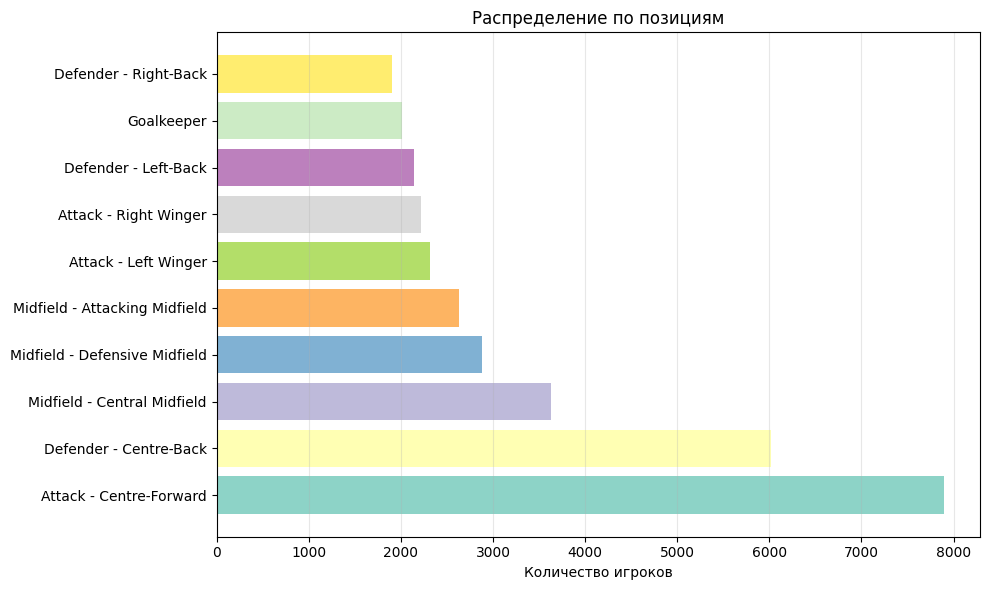

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# 5.2. Распределение по позициям
position_counts = df['position'].value_counts().head(10)
colors = plt.cm.Set3(np.linspace(0, 1, len(position_counts)))
ax.barh(position_counts.index, position_counts.values, color=colors)
ax.set_xlabel('Количество игроков')
ax.set_title('Распределение по позициям')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

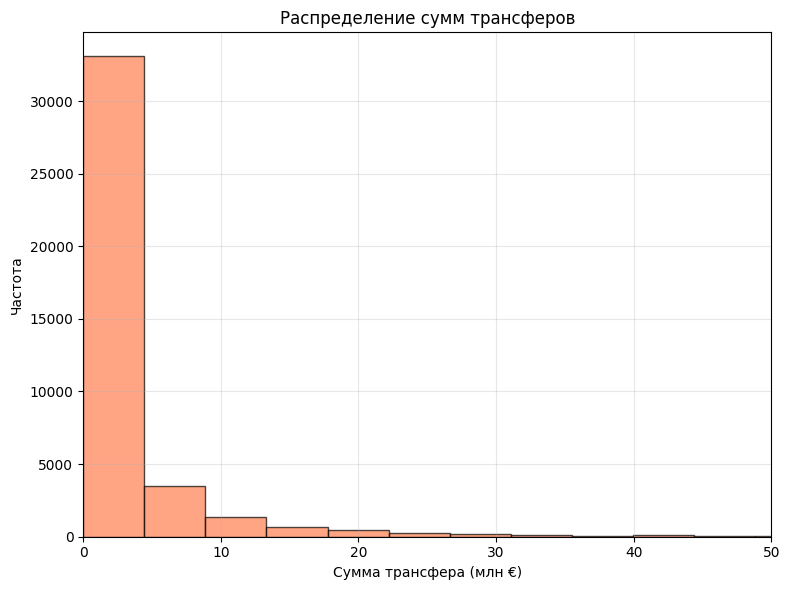

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# 5.3. Распределение стоимости трансферов
fee_millions = df['transfer_fee'] / 1_000_000
ax.hist(fee_millions, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Сумма трансфера (млн €)')
ax.set_ylabel('Частота')
ax.set_title('Распределение сумм трансферов')
ax.set_xlim([0, 50])
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

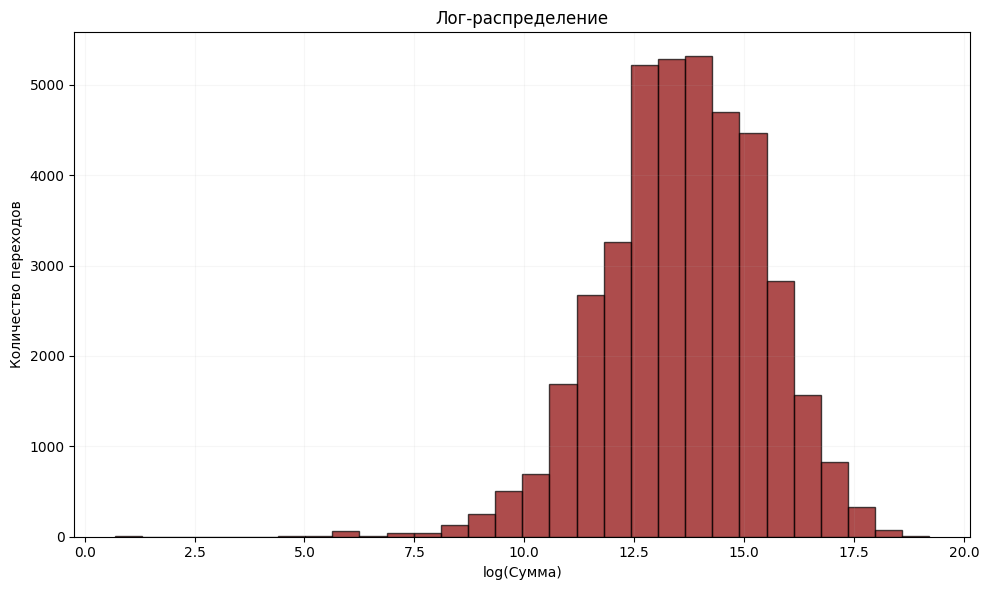

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Логарифмическим распределением
ax.hist(np.log1p(df['transfer_fee']), bins=30, color='darkred', edgecolor='black', alpha=0.7)
ax.set_xlabel('log(Сумма)')
ax.set_ylabel('Количество переходов')
ax.set_title('Лог-распределение')
ax.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11097/1330744224.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_avg = df.groupby('age_group_simple')['transfer_fee'].mean() / 1_000_000


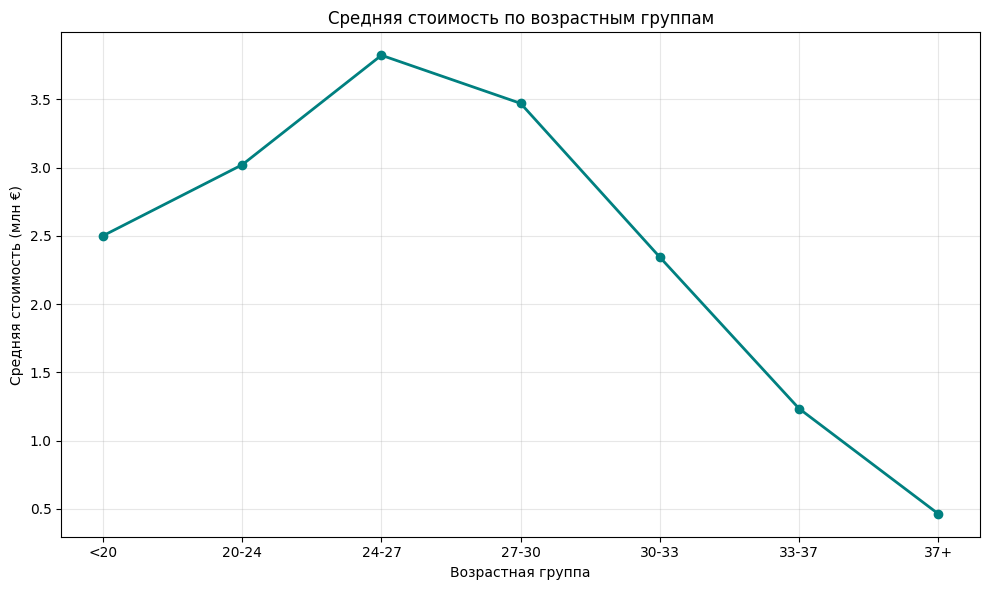

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# 5.4. Средняя стоимость по возрастным группам
age_groups = ['<20', '20-24', '24-27', '27-30', '30-33', '33-37', '37+']
df['age_group_simple'] = pd.cut(df['age'], bins=[0, 20, 24, 27, 30, 33, 37, 50],
                                 labels=age_groups)
age_group_avg = df.groupby('age_group_simple')['transfer_fee'].mean() / 1_000_000
age_group_avg.plot(kind='line', marker='o', ax=ax, color='teal', linewidth=2)
ax.set_xlabel('Возрастная группа')
ax.set_ylabel('Средняя стоимость (млн €)')
ax.set_title('Средняя стоимость по возрастным группам')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

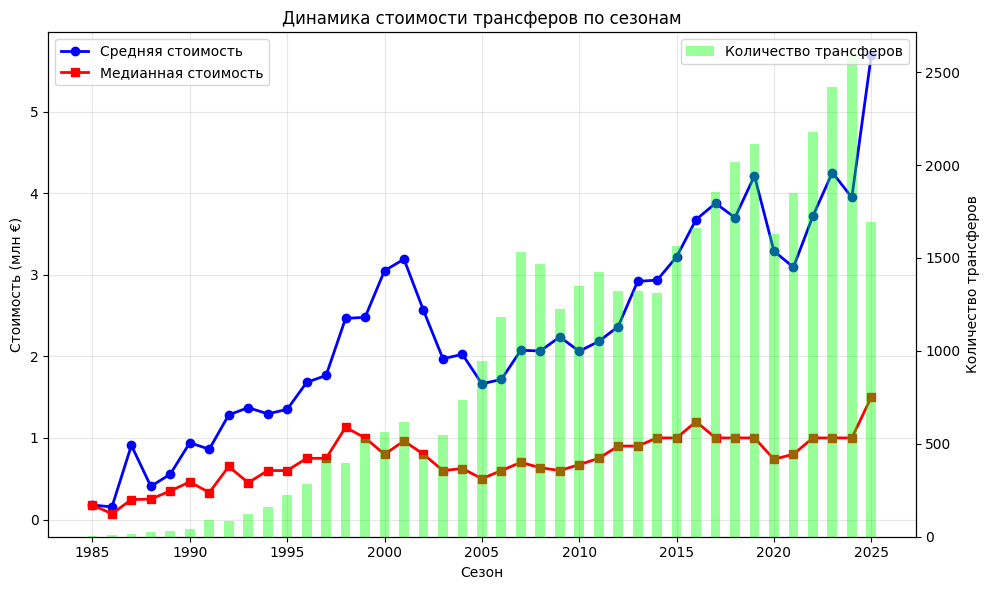

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# 5.5. Динамика стоимости по сезонам
season_stats = df.groupby('season_year').agg({
    'transfer_fee': ['mean', 'median', 'count']
}).round(0)
season_stats.columns = ['mean_fee', 'median_fee', 'count']
season_stats = season_stats[(season_stats.index >= 1985) & (season_stats.index < 2026)]

# Основной график стоимости
ax.plot(season_stats.index, season_stats['mean_fee'] / 1_000_000,
           marker='o', linewidth=2, markersize=6, color='blue', label='Средняя стоимость')
ax.plot(season_stats.index, season_stats['median_fee'] / 1_000_000,
           marker='s', linewidth=2, markersize=6, color='red', label='Медианная стоимость')
ax.set_xlabel('Сезон')
ax.set_ylabel('Стоимость (млн €)')
ax.set_title('Динамика стоимости трансферов по сезонам')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

# Вторая ось для количества трансферов
ax5_twin = ax.twinx()
ax5_twin.bar(season_stats.index, season_stats['count'], alpha=0.4, color='lime',
             width=0.5, label='Количество трансферов')
ax5_twin.set_ylabel('Количество трансферов')
ax5_twin.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# 6. Интеграция рыночной стоимости

market_values['date_unix'] = pd.to_datetime(market_values['date_unix'], errors='coerce')

market_values = market_values[market_values['value'] > 0]

print(f"Записей рыночной стоимости: {len(market_values):,}")
print(f"Уникальных игроков: {market_values['player_id'].nunique():,}")

Записей рыночной стоимости: 853,420
Уникальных игроков: 69,404


In [ ]:
df = df.sort_values('transfer_date')
market_values = market_values.sort_values('date_unix')

# Выполняем слияние ближайших дат
df = pd.merge_asof(
    df,
    market_values[['player_id', 'date_unix', 'value']],
    left_on='transfer_date',
    right_on='date_unix',
    by='player_id',
    direction='backward',
    tolerance=pd.Timedelta('365D')
)
print(f"После merge_asof: {len(df):,} записей")

После merge_asof: 39,997 записей


In [ ]:
df = df.rename(columns={'value': 'market_value'})

df['has_market_value'] = df['market_value'].notna()

df['temp_age_group'] = pd.cut(df['age'], bins=[0, 22, 27, 32, 100], labels=['young', 'prime', 'peak', 'veteran'])

market_value_medians = df[df['has_market_value']].groupby(['position', 'temp_age_group'])['market_value'].median().to_dict()

# Заполняем пропуски
for idx, row in df[~df['has_market_value']].iterrows():
    key = (row['position'], row['temp_age_group'])
    if key in market_value_medians and not pd.isna(market_value_medians[key]):
        df.loc[idx, 'market_value'] = market_value_medians[key]
    else:
        df.loc[idx, 'market_value'] = df[df['has_market_value']]['market_value'].median()

df['market_value_log'] = np.log1p(df['market_value'])

print(f"Записей с оригинальной market_value: {df['has_market_value'].sum():,} ({df['has_market_value'].sum()/len(df)*100:.1f}%)")
print(f"Записей с заполненной market_value: {(~df['has_market_value']).sum():,}")

df = df.drop(columns=['temp_age_group'])

/tmp/ipykernel_11097/2881483274.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  market_value_medians = df[df['has_market_value']].groupby(['position', 'temp_age_group'])['market_value'].median().to_dict()


Записей с оригинальной market_value: 26,831 (67.1%)
Записей с заполненной market_value: 13,166


In [ ]:
print(f"Доступные колонки в player_performances: {player_performances.columns.tolist()}")

player_performances['season_year'] = player_performances['season_name'].apply(extract_season_year)

ALL_STATS = [
    'goals', 'assists', 'minutes_played',
    'yellow_cards', 'direct_red_cards', 'second_yellow_cards',
    'own_goals', 'penalty_goals', 'goals_conceded', 'clean_sheets'
]

agg_dict = {}
for stat in ALL_STATS:
    if stat in player_performances.columns:
        agg_dict[stat] = 'sum'
    else:
        print(f"Колонка '{stat}' не найдена, пропускаем")

print(f"Агрегируем показатели: {list(agg_dict.keys())}")

Доступные колонки в player_performances: ['player_id', 'season_name', 'competition_id', 'competition_name', 'team_id', 'team_name', 'nb_in_group', 'nb_on_pitch', 'goals', 'assists', 'own_goals', 'subed_in', 'subed_out', 'yellow_cards', 'second_yellow_cards', 'direct_red_cards', 'penalty_goals', 'minutes_played', 'goals_conceded', 'clean_sheets']
Агрегируем показатели: ['goals', 'assists', 'minutes_played', 'yellow_cards', 'direct_red_cards', 'second_yellow_cards', 'own_goals', 'penalty_goals', 'goals_conceded', 'clean_sheets']


In [ ]:
player_performances = calculate_advanced_metrics(player_performances)

advanced_metrics = ['goals_assists_per_90', 'non_penalty_goals', 'clean_sheet_ratio']
for metric in advanced_metrics:
    if metric in player_performances.columns:
        agg_dict[metric] = 'mean'
        print(f"Добавлена продвинутая метрика: {metric}")

perf_agg = player_performances.groupby(['player_id', 'season_year']).agg(agg_dict).reset_index()
print(f"Агрегировано: {len(perf_agg)} записей")

Добавлена продвинутая метрика: goals_assists_per_90
Добавлена продвинутая метрика: non_penalty_goals
Добавлена продвинутая метрика: clean_sheet_ratio
Агрегировано: 784260 записей


In [ ]:
stat_columns = list(agg_dict.keys())

stats = []
missing_stats = 0

for idx, row in df.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"   Обработано {idx} трансферов")

    player_stats = perf_agg[
        (perf_agg['player_id'] == row['player_id']) &
        (perf_agg['season_year'] >= row['season_year'] - 2) &
        (perf_agg['season_year'] < row['season_year'])
    ]

    row_stats = {}
    if len(player_stats) == 0:
        missing_stats += 1
        # Если статистики нет, заполняем нулями
        for stat in stat_columns:
            row_stats[stat] = 0
    else:
        for stat in stat_columns:
            if stat in ['goals_assists_per_90', 'clean_sheet_ratio']:
                row_stats[stat] = player_stats[stat].mean()
            else:
                row_stats[stat] = player_stats[stat].sum()
    stats.append(row_stats)

stats_df = pd.DataFrame(stats)
print(f"Собрано статистики для {len(stats_df)} трансферов")
print(f"Трансферов без статистики за 2 года: {missing_stats} ({missing_stats/len(df)*100:.1f}%)")

   Обработано 1000 трансферов
   Обработано 2000 трансферов
   Обработано 3000 трансферов
   Обработано 4000 трансферов
   Обработано 5000 трансферов
   Обработано 6000 трансферов
   Обработано 7000 трансферов
   Обработано 8000 трансферов
   Обработано 9000 трансферов
   Обработано 10000 трансферов
   Обработано 11000 трансферов
   Обработано 12000 трансферов
   Обработано 13000 трансферов
   Обработано 14000 трансферов
   Обработано 15000 трансферов
   Обработано 16000 трансферов
   Обработано 17000 трансферов
   Обработано 18000 трансферов
   Обработано 19000 трансферов
   Обработано 20000 трансферов
   Обработано 21000 трансферов
   Обработано 22000 трансферов
   Обработано 23000 трансферов
   Обработано 24000 трансферов
   Обработано 25000 трансферов
   Обработано 26000 трансферов
   Обработано 27000 трансферов
   Обработано 28000 трансферов
   Обработано 29000 трансферов
   Обработано 30000 трансферов
   Обработано 31000 трансферов
   Обработано 32000 трансферов
   Обработано 330

In [ ]:
# Добавляем все показатели в основной датафрейм
for col in stats_df.columns:
    df[f'{col}_last_2y'] = stats_df[col]

    # Выводим статистику для ключевых показателей
    if col in ['goals', 'assists', 'minutes_played']:
        total = stats_df[col].sum()
        if col == 'minutes_played':
            print(f"   {col}_last_2y: {total:,.0f} минут")
        else:
            print(f"   {col}_last_2y: {total:,.0f}")

print(f"Всего добавлено показателей: {len(stats_df.columns)}")
print(f"В датафрейме теперь {len(df.columns)} колонок")

   goals_last_2y: 281,352
   assists_last_2y: 148,360
   minutes_played_last_2y: 45,700,107 минут
Всего добавлено показателей: 13
В датафрейме теперь 37 колонок


In [ ]:
# Травмы
player_injuries['from_date'] = pd.to_datetime(player_injuries['from_date'], errors='coerce')

injury_stats = []
for idx, row in df.iterrows():
    inj = player_injuries[
        (player_injuries['player_id'] == row['player_id']) &
        (player_injuries['from_date'] <= row['transfer_date'])
    ]
    injury_stats.append(inj['days_missed'].sum())

df['injury_days'] = injury_stats
print(f"Травмы: {df['injury_days'].sum():,.0f} пропущенных дней всего")
print(f"Игроков с травмами: {(df['injury_days'] > 0).sum()} ({((df['injury_days'] > 0).sum()/len(df)*100):.1f}%)")

Травмы: 1,721,605 пропущенных дней всего
Игроков с травмами: 13282 (33.2%)


In [ ]:
# Выступления за сборную
agg_dict_national = {'goals': 'sum'}

# Добавляем любые другие числовые колонки
for col in player_national.columns:
    if col not in ['player_id', 'season', 'season_name', 'date'] and col not in agg_dict_national:
        if player_national[col].dtype in ['int64', 'float64']:
            agg_dict_national[col] = 'sum'
            print(f"Дополнительная колонка для агрегации: {col}")

national_agg = player_national.groupby('player_id').agg(agg_dict_national).reset_index()

# Переименовываем колонки для понятности
rename_dict = {}
for col in agg_dict_national.keys():
    if col == 'goals':
        rename_dict[col] = 'national_goals'
    else:
        rename_dict[col] = f'national_{col}'

national_agg = national_agg.rename(columns=rename_dict)

# Объединяем с основным датафреймом
df = df.merge(national_agg, on='player_id', how='left')

# Заполняем пропуски нулями
for col in rename_dict.values():
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f"Игроков, забивавших за сборную: {(df['national_goals'] > 0).sum() if 'national_goals' in df.columns else 0}")
print(f"Всего голов за сборную: {df['national_goals'].sum():,.0f}" if 'national_goals' in df.columns else "Данные о голах за сборную отсутствуют")

Дополнительная колонка для агрегации: team_id
Дополнительная колонка для агрегации: matches
Дополнительная колонка для агрегации: shirt_number
Дополнительная колонка для агрегации: debut
Дополнительная колонка для агрегации: coach_id
Дополнительная колонка для агрегации: debut_game_id
Игроков, забивавших за сборную: 17316
Всего голов за сборную: 143,193


In [ ]:
# Финальный набор признаков

# Собираем все колонки с суффиксом _last_2y
performance_cols = [col for col in df.columns if col.endswith('_last_2y')]

# Категориальные признаки (позиция)
df['position_simple'] = df['position'].fillna('Unknown').apply(
    lambda x: x.split('-')[0] if pd.notna(x) and '-' in str(x) else str(x)
)

# Базовый список признаков
FEATURES = [
    'age', 'age_squared', 'market_value',
    'market_value_log', 'injury_days', 'national_goals'
] + performance_cols

# Проверяем наличие признаков
available_features = [f for f in FEATURES if f in df.columns]
print(f"Всего признаков в спецификации: {len(FEATURES)}")
print(f"Доступно в данных: {len(available_features)}")
print(f"Первые 10: {available_features[:10]}")

Всего признаков в спецификации: 19
Доступно в данных: 19
Первые 10: ['age', 'age_squared', 'market_value', 'market_value_log', 'injury_days', 'national_goals', 'goals_last_2y', 'assists_last_2y', 'minutes_played_last_2y', 'yellow_cards_last_2y']


In [ ]:
# Создаем финальный датасет
df_model = df[available_features + ['log_fee', 'season_year', 'transfer_fee', 'position_simple']].copy()

# Заполняем строки
for col in available_features:
    if col in df_model.columns:
        if df_model[col].dtype in ['int64', 'float64']:
            # Заполняем числовые колонки медианой
            median_val = df_model[col].median()
            df_model[col] = df_model[col].fillna(median_val)
        else:
            # Заполняем категориальные колонки модой
            mode_val = df_model[col].mode()[0] if not df_model[col].mode().empty else 'Unknown'
            df_model[col] = df_model[col].fillna(mode_val)

print(f"Финальный размер датасета: {len(df_model)} записей")

Финальный размер датасета: 39997 записей


In [ ]:
# Описательная статистика
print("Описательная статистика финального датасета:")
print(df_model[available_features].describe().T.to_string())

Описательная статистика финального датасета:
                                count          mean           std          min            25%           50%           75%           max
age                           39997.0  2.414564e+01  3.542269e+00      7.00000      22.000000  2.400000e+01  2.600000e+01  3.900000e+01
age_squared                   39997.0  5.955591e+02  1.753695e+02     49.00000     484.000000  5.760000e+02  6.760000e+02  1.521000e+03
market_value                  39997.0  2.899654e+06  6.114294e+06  10000.00000  700000.000000  1.350000e+06  2.250000e+06  1.500000e+08
market_value_log              39997.0  1.409520e+01  1.173157e+00      9.21044      13.458837  1.411562e+01  1.462644e+01  1.882615e+01
injury_days                   39997.0  4.304335e+01  1.019918e+02      0.00000       0.000000  0.000000e+00  3.300000e+01  3.467000e+03
national_goals                39997.0  3.580094e+00  8.401323e+00      0.00000       0.000000  0.000000e+00  3.000000e+00  1.590000e+02
goa

In [ ]:
# 10. Разделение данных
train = df[df['transfer_date'].dt.year <= 2021]
test = df[df['transfer_date'].dt.year > 2021]
X_train = train[available_features]
y_train = train['log_fee']
X_test = test[available_features]
y_test = test['log_fee']
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 11. Обучение моделей с расчётом метрик на обучении и тесте
models = {
    'Ridge (L2)': Ridge(alpha=1, random_state=42, max_iter=1000),
    'Lasso (L1)': Lasso(alpha=0.001, random_state=42, max_iter=1000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=6, subsample=0.8, random_state=42)
}

results_train = []
results_test = []
best_model = None
best_r2_test = -np.inf

for name, model in models.items():
    print(f"\nОбучение: {name}")
    if name in ['Ridge (L2)', 'Lasso (L1)']:
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

    y_pred_train_real = np.expm1(y_pred_train)
    y_pred_test_real = np.expm1(y_pred_test)

    # Метрики на обучении
    mae_train = mean_absolute_error(y_train_real, y_pred_train_real)
    r2_train = r2_score(y_train_real, y_pred_train_real)
    mape_train = mean_absolute_percentage_error(y_train_real, y_pred_train_real)
    results_train.append({'Модель': name, 'MAE_train (€)': mae_train, 'R^2_train': r2_train, 'MAPE_train (%)': mape_train})

    # Метрики на тесте
    mae_test = mean_absolute_error(y_test_real, y_pred_test_real)
    r2_test = r2_score(y_test_real, y_pred_test_real)
    mape_test = mean_absolute_percentage_error(y_test_real, y_pred_test_real)
    results_test.append({'Модель': name, 'MAE_test (€)': mae_test, 'R^2_test': r2_test, 'MAPE_test (%)': mape_test})

    print(f"   Train: MAE = €{mae_train:,.0f}, R² = {r2_train:.4f}, MAPE = {mape_train:.1f}%")
    print(f"   Test : MAE = €{mae_test:,.0f}, R² = {r2_test:.4f}, MAPE = {mape_test:.1f}%")

    if r2_test > best_r2_test:
        best_r2_test = r2_test
        best_model = model
        best_model_name = name


Обучение: Ridge (L2)
   Train: MAE = €2,794,550, R² = -70.3750, MAPE = 32.3%
   Test : MAE = €3,999,126, R² = -130.0120, MAPE = 43.5%

Обучение: Lasso (L1)
   Train: MAE = €2,748,704, R² = -65.0703, MAPE = 33.1%
   Test : MAE = €3,875,680, R² = -109.6928, MAPE = 42.9%

Обучение: Random Forest
   Train: MAE = €1,307,607, R² = 0.7643, MAPE = 13.0%
   Test : MAE = €1,755,481, R² = 0.7837, MAPE = 50.7%

Обучение: Gradient Boosting
   Train: MAE = €1,359,944, R² = 0.7566, MAPE = 12.8%
   Test : MAE = €1,761,442, R² = 0.7763, MAPE = 54.0%


In [ ]:
# Сводная таблица сравнения train/test
print("Сравнение метрик на обучающей и тестовой выборках")
train_df = pd.DataFrame(results_train).sort_values('R^2_train', ascending=False)
test_df = pd.DataFrame(results_test).sort_values('R^2_test', ascending=False)
comparison = pd.merge(train_df, test_df, on='Модель', suffixes=('_train', '_test'))

print(comparison[['Модель', 'R^2_train', 'R^2_test', 'MAE_train (€)', 'MAE_test (€)']].to_string(index=False))
print(f"\nЛучшая модель: {best_model_name} (R²_test = {best_r2_test:.4f})")

Сравнение метрик на обучающей и тестовой выборках
           Модель  R^2_train    R^2_test  MAE_train (€)  MAE_test (€)
    Random Forest   0.764265    0.783741   1.307607e+06  1.755481e+06
Gradient Boosting   0.756639    0.776330   1.359944e+06  1.761442e+06
       Lasso (L1) -65.070346 -109.692789   2.748704e+06  3.875680e+06
       Ridge (L2) -70.374971 -130.011989   2.794550e+06  3.999126e+06

Лучшая модель: Random Forest (R²_test = 0.7837)



Топ-10 важнейших признаков (feature_importances_):
    4. market_value_log                   : 0.3782 (37.8%)
    3. market_value                       : 0.3655 (36.6%)
    6. national_goals                     : 0.0674 (6.7%)
   10. yellow_cards_last_2y               : 0.0368 (3.7%)
    9. minutes_played_last_2y             : 0.0270 (2.7%)
    2. age_squared                        : 0.0259 (2.6%)
    1. age                                : 0.0251 (2.5%)
    8. assists_last_2y                    : 0.0217 (2.2%)
   17. goals_assists_per_90_last_2y       : 0.0121 (1.2%)
    7. goals_last_2y                      : 0.0110 (1.1%)


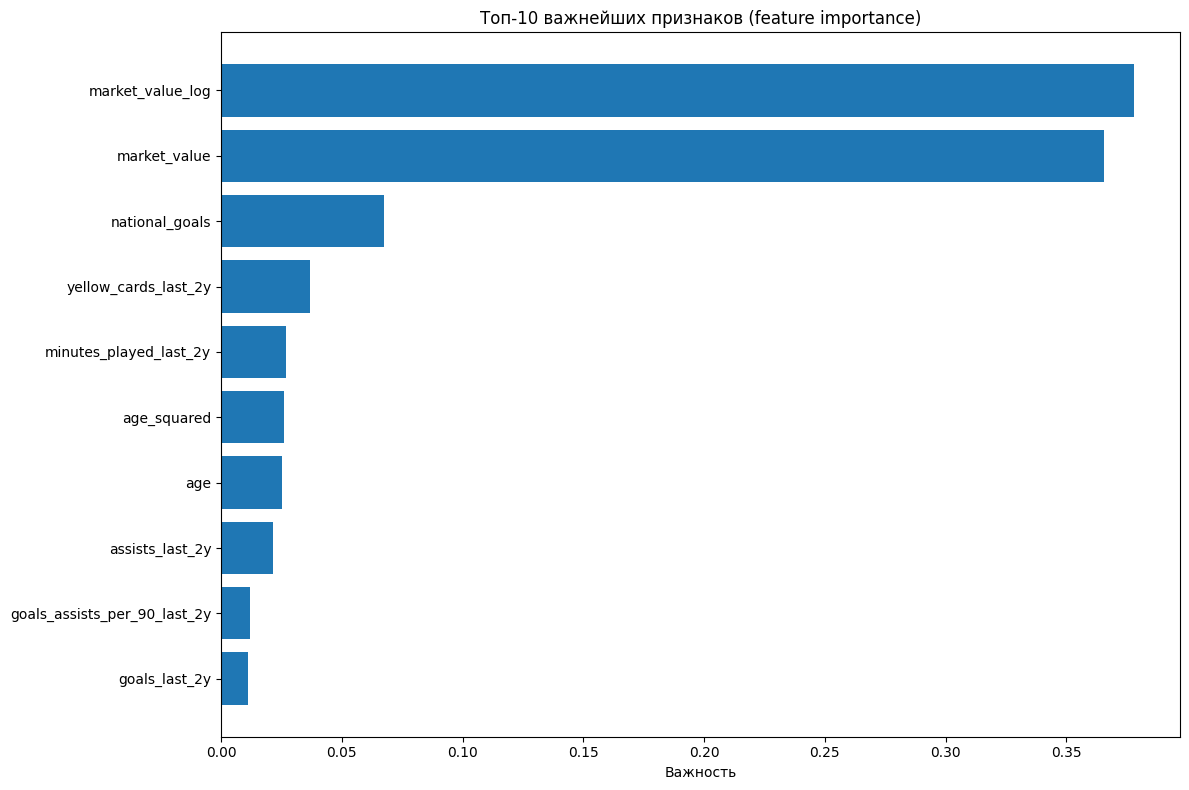


Permutation importance анализ...
Топ-10 по permutation importance:
    4. market_value_log                   : 0.3475 ± 0.0073
    3. market_value                       : 0.3141 ± 0.0066
    6. national_goals                     : 0.0181 ± 0.0021
    1. age                                : 0.0114 ± 0.0008
    2. age_squared                        : 0.0112 ± 0.0009
   10. yellow_cards_last_2y               : 0.0080 ± 0.0010
    9. minutes_played_last_2y             : 0.0043 ± 0.0008
    5. injury_days                        : 0.0024 ± 0.0005
    8. assists_last_2y                    : 0.0022 ± 0.0005
    7. goals_last_2y                      : 0.0018 ± 0.0005


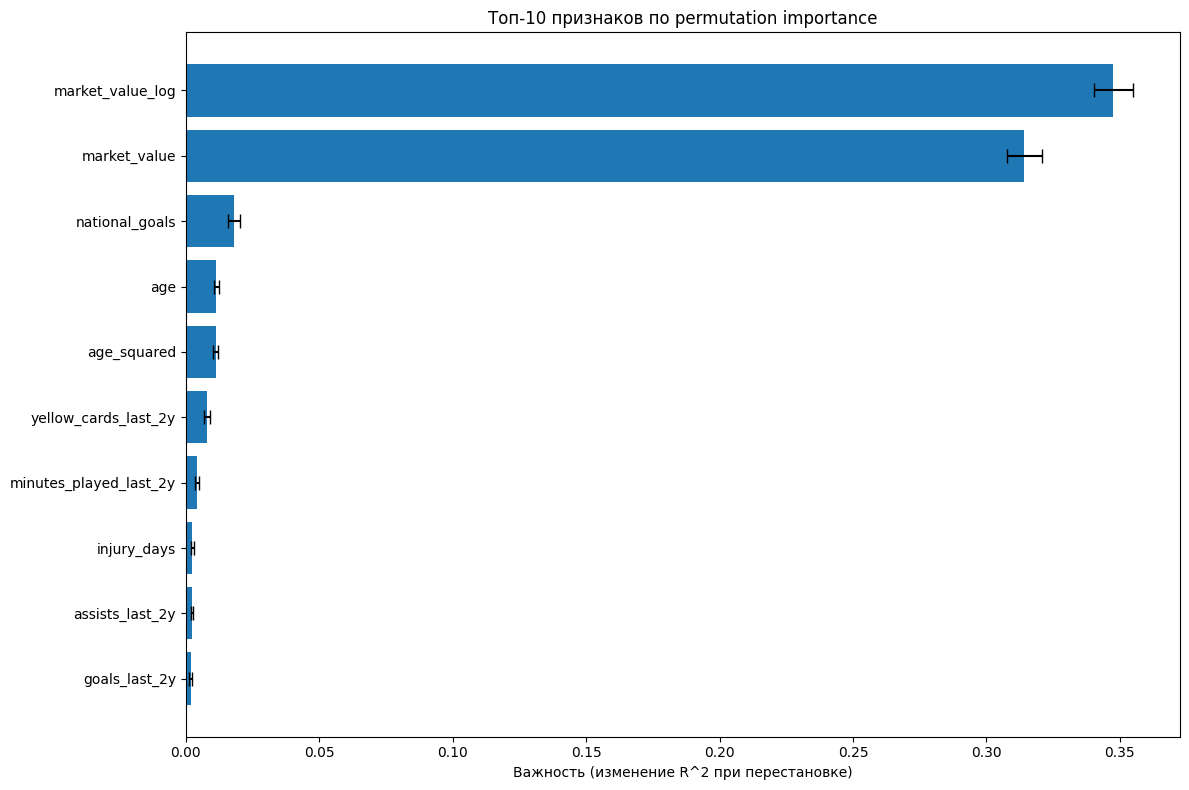

In [ ]:
# 12. Анализ важности признаков

# Определяем, с какими данными работаем
use_scaled = 'Ridge' in best_model_name or 'Lasso' in best_model_name
X_test_best = X_test_scaled if use_scaled else X_test

# 12.1. Встроенная важность для древовидных моделей
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Признак': available_features,
        'Важность': best_model.feature_importances_
    }).sort_values('Важность', ascending=False)

    print("\nТоп-10 важнейших признаков (feature_importances_):")
    for i, row in importance.head(10).iterrows():
        print(f"   {i+1:2d}. {row['Признак']:35s}: {row['Важность']:.4f} ({row['Важность']*100:.1f}%)")

    # Визуализация
    plt.figure(figsize=(12, 8))
    plt.barh(importance['Признак'].head(10), importance['Важность'].head(10))
    plt.xlabel('Важность')
    plt.title('Топ-10 важнейших признаков (feature importance)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


# 12.2. Permutation importance (для всех моделей)
print("\nPermutation importance анализ...")
perm = permutation_importance(
    best_model, X_test_best, y_test,
    n_repeats=10, random_state=42, scoring='r2', n_jobs=-1
)

perm_importance = pd.DataFrame({
    'Признак': available_features,
    'Важность': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Важность', ascending=False)

print("Топ-10 по permutation importance:")
for i, row in perm_importance.head(10).iterrows():
    print(f"   {i+1:2d}. {row['Признак']:35s}: {row['Важность']:.4f} ± {row['Std']:.4f}")

# Визуализация permutation importance
plt.figure(figsize=(12, 8))
plt.barh(perm_importance['Признак'].head(10), perm_importance['Важность'].head(10),
         xerr=perm_importance['Std'].head(10), capsize=5)
plt.xlabel('Важность (изменение R^2 при перестановке)')
plt.title('Топ-10 признаков по permutation importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# 13. Анализ конкретных трансферов

def find_player(player_name):
    # Поиск игрока по имени в профилях
    if player_profiles.empty:
        print("   Данные профилей не загружены")
        return None

    matches = player_profiles[
        player_profiles['player_name'].str.contains(player_name, case=False, na=False)
    ]

    if len(matches) == 0:
        print(f"   Игрок '{player_name}' не найден")
        return None

    print(f"   Найдено {len(matches)} совпадений:")
    for i, (_, row) in enumerate(matches.iterrows()):
        print(f"      {i+1}. {row['player_name']} (ID: {row['player_id']})")

    return matches.iloc[0]

def analyze_player_transfer(player_id, target_year):
    # Анализ конкретного трансфера игрока

    # Поиск трансфера
    transfer = df[
        (df['player_id'] == player_id) &
        (df['season_year'] == target_year)
    ]

    if len(transfer) == 0:
        print(f"   Трансфер {target_year} года не найден")

        # Показываем доступные трансферы
        player_transfers = df[df['player_id'] == player_id].sort_values('season_year')
        if len(player_transfers) > 0:
            print("   Доступные трансферы:")
            for _, t in player_transfers.iterrows():
                from_team = t.get('from_team_name', 'Unknown')
                to_team = t.get('to_team_name', 'Unknown')
                print(f"      • {t['season_year']}: {from_team} → {to_team} (€{t['transfer_fee']:,.0f})")
        return None

    data = transfer.iloc[0]

    # Формируем признаки для модели
    profile_data = {}
    for feat in available_features:
        profile_data[feat] = data.get(feat, 0)

    profile = pd.DataFrame([profile_data])[available_features]

    # Масштабирование для линейных моделей
    if use_scaled:
        profile_scaled = scaler.transform(profile)
        pred_log = best_model.predict(profile_scaled)[0]
    else:
        pred_log = best_model.predict(profile)[0]

    pred_value = np.expm1(pred_log)
    actual = data['transfer_fee']

    if actual > 0:
        error_abs = abs(actual - pred_value)
        error_pct = ((error_abs / actual) * 100)
    else:
        error_abs = 0
        error_pct = 0

    # Получаем имя игрока
    player_info = player_profiles[player_profiles['player_id'] == player_id]
    player_name = player_info.iloc[0]['player_name'] if len(player_info) > 0 else "Неизвестно"

    # Детальный вывод
    print(f"Анализ трансфера: {player_name}")
    print(f"   Год трансфера:    {data['season_year']}")
    print(f"   Возраст:          {data['age']:.1f} лет")
    print(f"   Позиция:          {data.get('position', 'Unknown')}")
    print(f"   Фактическая сумма: €{actual:,.0f} (€{actual/1_000_000:.2f}M)")
    print(f"   Прогноз модели:    €{pred_value:,.0f} (€{pred_value/1_000_000:.2f}M)")
    print(f"   Абсолютная ошибка: €{error_abs:,.0f}")
    print(f"   Относительная ошибка: {error_pct:.1f}%")


    return {
        'player_name': player_name,
        'season': data['season_year'],
        'age': data['age'],
        'position': data.get('position', 'Unknown'),
        'actual_fee': actual,
        'predicted_fee': pred_value,
        'error_abs': error_abs,
        'error': error_pct
    }

# Список игроков для анализа
players_to_analyze = [
    ("Karim Benzema", 2009),
    ("Zlatan Ibrahimović", 2011),
    ("Antoine Griezmann", 2019),
    ("Luis Suárez", 2022),
    ("Kristjan Asllani", 2023),
    ("Arnau Tenas", 2025)
]

case_studies = []

print("Анализ известных трансферов")

for player_name, year in players_to_analyze:
    print(f"\nПоиск: {player_name} ({year})")
    player = find_player(player_name)

    if player is not None:
        result = analyze_player_transfer(player['player_id'], year)
        if result is not None:
            case_studies.append(result)

# Сводная таблица кейсов
case_df = pd.DataFrame(case_studies)
print("\nСводная таблица результатов анализа")

# Форматирование для вывода
display_df = case_df.copy()
display_df['actual_fee'] = display_df['actual_fee'].apply(lambda x: f"€{x/1_000_000:.1f}M")
display_df['predicted_fee'] = display_df['predicted_fee'].apply(lambda x: f"€{x/1_000_000:.1f}M")
display_df['error'] = display_df['error'].apply(lambda x: f"{x:.1f}%")

print(display_df[['player_name', 'season', 'actual_fee', 'predicted_fee', 'error']].to_string(index=False))

Анализ известных трансферов

Поиск: Karim Benzema (2009)
   Найдено 1 совпадений:
      1. Karim Benzema (18922) (ID: 18922)
Анализ трансфера: Karim Benzema (18922)
   Год трансфера:    2009
   Возраст:          22.0 лет
   Позиция:          Attack - Centre-Forward
   Фактическая сумма: €35,000,000 (€35.00M)
   Прогноз модели:    €31,717,937 (€31.72M)
   Абсолютная ошибка: €3,282,063
   Относительная ошибка: 9.4%

Поиск: Zlatan Ibrahimović (2011)
   Найдено 1 совпадений:
      1. Zlatan Ibrahimović (3455) (ID: 3455)
Анализ трансфера: Zlatan Ibrahimović (3455)
   Год трансфера:    2011
   Возраст:          30.0 лет
   Позиция:          Attack - Centre-Forward
   Фактическая сумма: €24,000,000 (€24.00M)
   Прогноз модели:    €26,997,858 (€27.00M)
   Абсолютная ошибка: €2,997,858
   Относительная ошибка: 12.5%

Поиск: Antoine Griezmann (2019)
   Найдено 1 совпадений:
      1. Antoine Griezmann (125781) (ID: 125781)
Анализ трансфера: Antoine Griezmann (125781)
   Год трансфера:    2019
   